# Butterfly Diffusion Model (Smithsonian Dataset)

This notebook implements a basic diffusion model pipeline using the Smithsonian butterflies dataset.

Steps:
1. Load dataset
2. Visualize samples
3. Preprocess images
4. Prepare for training

In [35]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [36]:
import torch
from torchvision import transforms


In [37]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),  # converts to [0,1]
    transforms.Normalize([0.5]*3, [0.5]*3)  # scale to [-1,1]
])

## Load Dataset

We use the Smithsonian butterflies subset from Hugging Face.

In [38]:
from datasets import load_dataset

dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

print("Total images:", len(dataset))

Repo card metadata block was not found. Setting CardData to empty.


Total images: 1000


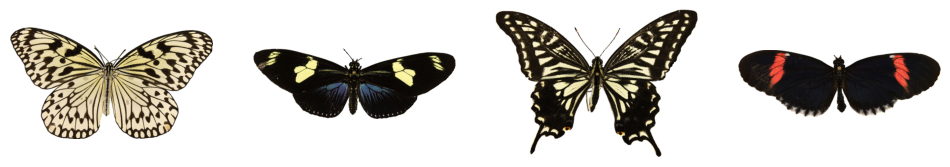

In [39]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(12, 3))

for i, image in enumerate(dataset[:4]["image"]):
    axs[i].imshow(image)
    axs[i].axis("off")

plt.show()

In [40]:
sample = dataset[0]
print(sample)
print(type(sample["image"]))

{'image_url': 'https://ids.si.edu/ids/deliveryService?id=ark:/65665/m3b302800a43ef46b8a7a87a7b1eb06ab6', 'image_alt': 'view Paper Kite digital asset number 1', 'id': 'ark:/65665/m3b302800a43ef46b8a7a87a7b1eb06ab6', 'name': 'Paper Kite', 'scientific_name': 'Idea leuconoe', 'gender': None, 'taxonomy': 'Animalia, Arthropoda, Hexapoda, Insecta, Lepidoptera, Nymphalidae', 'region': 'US Mid Atlantic (PA, NJ, MD, DE, DC, VA, WV)', 'locality': 'NMNH Butterfly Pavilion, North America, United States, District of Columbia', 'date': None, 'usnm_no': 'EO401041', 'guid': 'http://n2t.net/ark:/65665/35f90bc1d-2e3c-4798-a33c-611d7b358636', 'edan_url': 'edanmdm:nmnheducation_11038234', 'source': 'Smithsonian Education and Outreach collections', 'stage': None, 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x283 at 0x77D99130CB90>, 'image_hash': 'fb0b8749d437efc70a26e54212b3572c', 'sim_score': 0.8055200576782227}
<class 'PIL.PngImagePlugin.PngImageFile'>


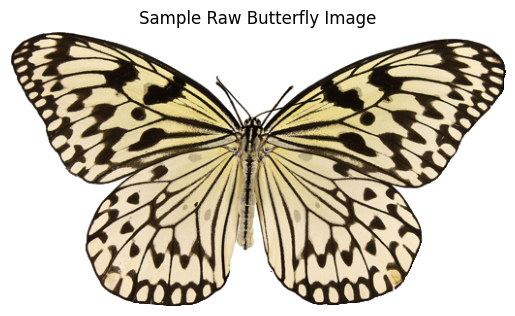

In [41]:
img = dataset[0]["image"]

plt.imshow(img)
plt.title("Sample Raw Butterfly Image")
plt.axis("off")
plt.show()

## Preprocessing

Resize images to a fixed resolution and normalize pixel values to the [-1, 1] range required for diffusion models.

In [42]:
preprocess = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

In [43]:
def transform_examples(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

In [44]:
dataset.set_transform(transform_examples)

In [45]:
sample = dataset[0]
print(sample.keys())
print(sample["images"].shape)
print(sample["images"].min(), sample["images"].max())

dict_keys(['images'])
torch.Size([3, 64, 64])
tensor(-0.9451) tensor(1.)


## Visualize a Preprocessed Image

Display one transformed sample after converting it back from tensor format for viewing.

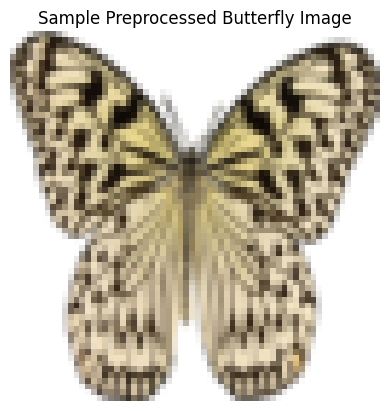

In [46]:
img = dataset[0]["images"]
img_display = (img * 0.5 + 0.5).permute(1, 2, 0)

plt.imshow(img_display)
plt.title("Sample Preprocessed Butterfly Image")
plt.axis("off")
plt.show()

## Create DataLoader

Wrap the dataset into batches for training.

In [47]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

In [48]:
batch = next(iter(train_dataloader))

print(batch.keys())
print(batch["images"].shape)

dict_keys(['images'])
torch.Size([16, 3, 64, 64])


## Define Diffusion Model (UNet)

We use a UNet architecture to predict noise added during the diffusion process.

In [49]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=64,        # matches your image size
    in_channels=3,         # RGB images
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

In [50]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("Device:", device)

sample = batch["images"].to(device)
out = model(sample, timestep=0).sample

print("Input:", sample.shape)
print("Output:", out.shape)

Device: cuda
Input: torch.Size([16, 3, 64, 64])
Output: torch.Size([16, 3, 64, 64])


## Noise Scheduler (DDPM)

We simulate the forward diffusion process by adding noise to images.
The model learns to predict this noise.

In [51]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

In [52]:
noise = torch.randn(sample.shape).to(device)

timesteps = torch.randint(
    0,
    noise_scheduler.config.num_train_timesteps,
    (sample.shape[0],),
    device=device
).long()

noisy_images = noise_scheduler.add_noise(sample, noise, timesteps)

print(noisy_images.shape)

torch.Size([16, 3, 64, 64])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4477046..2.402937].


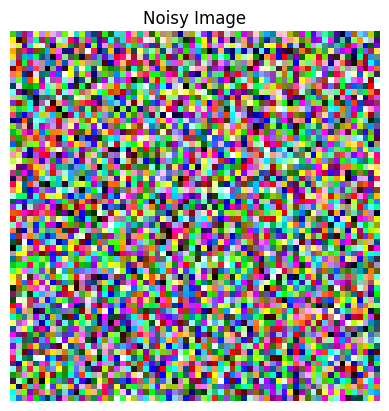

In [53]:
img = noisy_images[0].detach().cpu()
img_display = (img * 0.5 + 0.5).permute(1, 2, 0)

plt.imshow(img_display)
plt.title("Noisy Image")
plt.axis("off")
plt.show()

## Visualize Forward Diffusion

Show how a clean butterfly image gradually becomes noisier as diffusion timesteps increase.

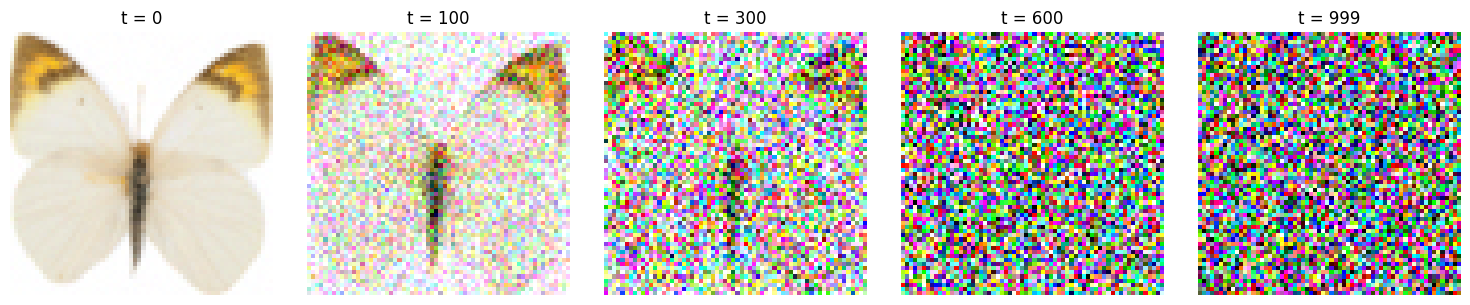

In [54]:
import matplotlib.pyplot as plt

single_image = batch["images"][0].unsqueeze(0).to(device)

timesteps_to_show = [0, 100, 300, 600, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t in enumerate(timesteps_to_show):
    noise = torch.randn_like(single_image)
    timestep = torch.tensor([t], device=device).long()
    noisy_image = noise_scheduler.add_noise(single_image, noise, timestep)

    img = noisy_image[0].detach().cpu()
    img_display = (img * 0.5 + 0.5).permute(1, 2, 0).clamp(0, 1)

    axes[i].imshow(img_display)
    axes[i].set_title(f"t = {t}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [55]:
import torch.nn.functional as F

## Training Objective

The diffusion model is trained to predict the noise added to an image.
We use Mean Squared Error (MSE) loss between the predicted noise and the true noise.

In [56]:
batch_images = batch["images"].to(device)

noise = torch.randn_like(batch_images)

timesteps = torch.randint(
    0,
    noise_scheduler.config.num_train_timesteps,
    (batch_images.shape[0],),
    device=device
).long()

noisy_images = noise_scheduler.add_noise(batch_images, noise, timesteps)

noise_pred = model(noisy_images, timesteps).sample

loss = F.mse_loss(noise_pred, noise)

print("Loss:", loss.item())

Loss: 1.1463836431503296


In [58]:
import os
import torch.nn.functional as F
from diffusers import DDPMPipeline

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

num_epochs = 70

os.makedirs("outputs", exist_ok=True)
losses = []
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}")

    model.train()

    for step, batch in enumerate(train_dataloader):
        batch_images = batch["images"].to(device)

        noise = torch.randn_like(batch_images)

        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_images.shape[0],),
            device=device
        ).long()

        noisy_images = noise_scheduler.add_noise(batch_images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps).sample

        loss = F.mse_loss(noise_pred, noise)
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 50 == 0:
            print(f"Step {step} | Loss: {loss.item():.4f}")

    if (epoch + 1) % 10 == 0:
        model.eval()

        pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
        pipeline = pipeline.to(device)

        generated_images = pipeline(
            batch_size=4,
            generator=torch.manual_seed(42)
        ).images

        for i, img in enumerate(generated_images):
            img.save(f"outputs/epoch_{epoch + 1}_img_{i}.png")

        print(f"Saved images for epoch {epoch + 1}")


Epoch 1
Step 0 | Loss: 0.0718
Step 50 | Loss: 0.0714

Epoch 2
Step 0 | Loss: 0.0360
Step 50 | Loss: 0.0178

Epoch 3
Step 0 | Loss: 0.0306
Step 50 | Loss: 0.0802

Epoch 4
Step 0 | Loss: 0.0469
Step 50 | Loss: 0.0253

Epoch 5
Step 0 | Loss: 0.0241
Step 50 | Loss: 0.0320

Epoch 6
Step 0 | Loss: 0.0111
Step 50 | Loss: 0.0166

Epoch 7
Step 0 | Loss: 0.0279
Step 50 | Loss: 0.0252

Epoch 8
Step 0 | Loss: 0.0206
Step 50 | Loss: 0.0094

Epoch 9
Step 0 | Loss: 0.0113
Step 50 | Loss: 0.0102

Epoch 10
Step 0 | Loss: 0.0074
Step 50 | Loss: 0.0361


100%|██████████| 1000/1000 [00:10<00:00, 98.94it/s]


Saved images for epoch 10

Epoch 11
Step 0 | Loss: 0.0382
Step 50 | Loss: 0.0837

Epoch 12
Step 0 | Loss: 0.0414
Step 50 | Loss: 0.0115

Epoch 13
Step 0 | Loss: 0.0120
Step 50 | Loss: 0.0691

Epoch 14
Step 0 | Loss: 0.0597
Step 50 | Loss: 0.0127

Epoch 15
Step 0 | Loss: 0.0280
Step 50 | Loss: 0.0206

Epoch 16
Step 0 | Loss: 0.0302
Step 50 | Loss: 0.0188

Epoch 17
Step 0 | Loss: 0.0134
Step 50 | Loss: 0.0201

Epoch 18
Step 0 | Loss: 0.0334
Step 50 | Loss: 0.0261

Epoch 19
Step 0 | Loss: 0.0225
Step 50 | Loss: 0.0297

Epoch 20
Step 0 | Loss: 0.0319
Step 50 | Loss: 0.0262


100%|██████████| 1000/1000 [00:10<00:00, 98.95it/s]


Saved images for epoch 20

Epoch 21
Step 0 | Loss: 0.0321
Step 50 | Loss: 0.0739

Epoch 22
Step 0 | Loss: 0.0350
Step 50 | Loss: 0.0092

Epoch 23
Step 0 | Loss: 0.0101
Step 50 | Loss: 0.0609

Epoch 24
Step 0 | Loss: 0.0522
Step 50 | Loss: 0.0113

Epoch 25
Step 0 | Loss: 0.0249
Step 50 | Loss: 0.0176

Epoch 26
Step 0 | Loss: 0.0273
Step 50 | Loss: 0.0167

Epoch 27
Step 0 | Loss: 0.0117
Step 50 | Loss: 0.0178

Epoch 28
Step 0 | Loss: 0.0297
Step 50 | Loss: 0.0238

Epoch 29
Step 0 | Loss: 0.0203
Step 50 | Loss: 0.0267

Epoch 30
Step 0 | Loss: 0.0295
Step 50 | Loss: 0.0240


...

Saved images for epoch 50

Epoch 51
Step 0 | Loss: 0.0264
Step 50 | Loss: 0.0594

Epoch 52
Step 0 | Loss: 0.0278
Step 50 | Loss: 0.0070

Epoch 53
Step 0 | Loss: 0.0081
Step 50 | Loss: 0.0500

Epoch 54
Step 0 | Loss: 0.0433
Step 50 | Loss: 0.0086

Epoch 55
Step 0 | Loss: 0.0203
Step 50 | Loss: 0.0136

Epoch 56
Step 0 | Loss: 0.0225
Step 50 | Loss: 0.0136

Epoch 57
Step 0 | Loss: 0.0100
Step 50 | Loss: 0.0145

Epoch 58
Step 0 | Loss: 0.0237
Step 50 | Loss: 0.0202

Epoch 59
Step 0 | Loss: 0.0171
Step 50 | Loss: 0.0217

Epoch 60
Step 0 | Loss: 0.0237
Step 50 | Loss: 0.0206


100%|██████████| 1000/1000 [00:10<00:00, 99.54it/s]


Saved images for epoch 60

Epoch 61
Step 0 | Loss: 0.0252
Step 50 | Loss: 0.0564

Epoch 62
Step 0 | Loss: 0.0262
Step 50 | Loss: 0.0067

Epoch 63
Step 0 | Loss: 0.0076
Step 50 | Loss: 0.0476

Epoch 64
Step 0 | Loss: 0.0413
Step 50 | Loss: 0.0079

Epoch 65
Step 0 | Loss: 0.0190
Step 50 | Loss: 0.0126

Epoch 66
Step 0 | Loss: 0.0210
Step 50 | Loss: 0.0132

Epoch 67
Step 0 | Loss: 0.0097
Step 50 | Loss: 0.0137

Epoch 68
Step 0 | Loss: 0.0225
Step 50 | Loss: 0.0192

Epoch 69
Step 0 | Loss: 0.0159
Step 50 | Loss: 0.0212

Epoch 70
Step 0 | Loss: 0.0227
Step 50 | Loss: 0.0196


100%|██████████| 1000/1000 [00:10<00:00, 99.56it/s]

Saved images for epoch 70


## Training Loss Visualization

We plot the MSE loss during training to observe whether the model is learning to predict the added noise.


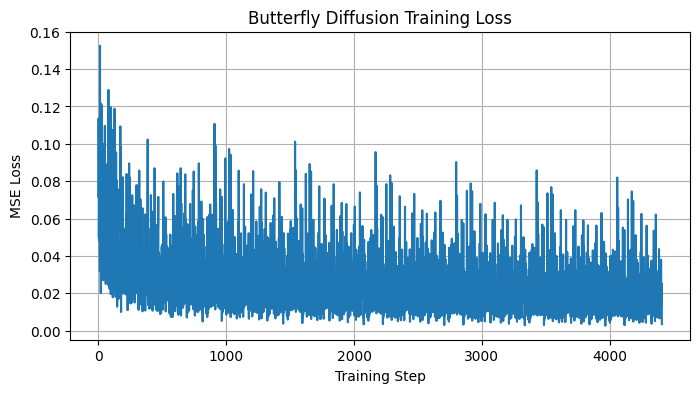

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Butterfly Diffusion Training Loss")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

## Generate Images

Use the trained model to reverse the diffusion process and generate butterfly images from random noise.

In [60]:
from diffusers import DDPMPipeline

pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
pipeline = pipeline.to(device)

In [61]:
import torch

generated_images = pipeline(
    batch_size=4,
    generator=torch.manual_seed(42)
).images

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:09<00:00, 101.98it/s]


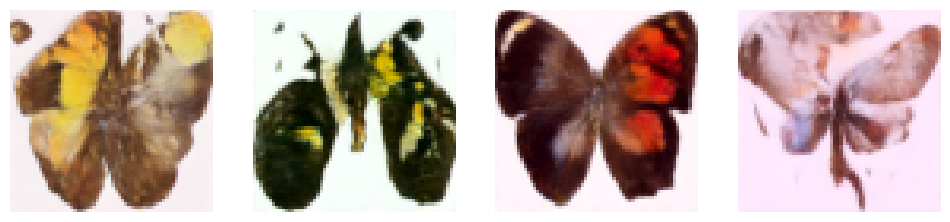

In [63]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

for i, img in enumerate(generated_images):
    axs[i].imshow(img)
    axs[i].axis("off")

plt.show()      

## Final Results

After training for 70 epochs, the model is able to generate butterfly-like images with:

- Symmetrical wing structures  
- Coherent color distributions  
- Distinct object boundaries  
    
However, the generated images are still somewhat blurry, indicating that further training or a larger model could improve fine details.

This demonstrates that the diffusion pipeline is working correctly and learning meaningful data representations.

pipeline.save_pretrained("outputs/butterfly_model")